### Outcome Based Metric Plots

In this notebook we're collecting statistics for the rollouts of experiment 13 and provide visualizations.

1) plot the pass@k curves
2) plot initial solverate versus final solverate

In [15]:
outcome_based_plotdir = "/u/rfechner/verl/plots/outcome_based"

In [2]:
import os
import pickle
import pathlib
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
from util import rollouts

In [4]:
passk = rollouts(recompute=False)

In [5]:
models = set([x.split('__')[0] for x in passk.keys()])
methods = set([x.split('__')[1] for x in passk.keys()])
models, methods

({'eurollm_9b_instruct',
  'llama_3.1_8b_instruct',
  'qwen2.5_1.5b',
  'qwen2.5_7b'},
 {'grpo-passk', 'grpo-s', 'gspo', 'kl-cov'})

In [ ]:
# we have to correct for the base model archiving different pass@k values. In this analysis we'll just take the first estimate.
base_model_mapper = {model : None for model in set([m.split('__')[0] for m in passk.keys()])}
for method in passk.keys():
    m = method.split('__')[0]
    if base_model_mapper[m] is None:
        base_model_mapper[m] = passk[method]['0']
    

    assert all([
        np.allclose(base_model_mapper[m][k], passk[method]['0'][k]) for k in passk[method]['0'].keys()
    ])


In [37]:
method_name_mapper = {
    'grpo-s' : "GRPO-S",
    'grpo-passk' : "Pass@k Training",
    'gspo' : "GSPO",
    'kl-cov' : "KL-Cov"
}
model_name_mapper = {
    'qwen2.5_7b' : "Qwen2.5-7B",
    "eurollm_9b_instruct" : "EuroLLM-9B-Instruct",
    "qwen2.5_1.5b": "Qwen2.5-1.5B",
    "llama_3.1_8b_instruct" : "Llama3.1-8B-Instruct"
}

In [ ]:
def plot_pass_rates(passrates_per_method):
    methods = list(passrates_per_method.keys())
    n_methods = len(methods)

    # Collect all dataset names (validation data sources)
    datasets = sorted({
        ds for method_data in passrates_per_method.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    n_datasets = len(datasets)

    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(3 * n_methods, 3 * n_datasets),
        sharey='row',
        squeeze=False
    )

    for j, method in enumerate(methods):
        method_data = passrates_per_method[method]

        # Collect all checkpoints and sort numerically
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        n_ckpts = len(checkpoints)
        cmap = plt.get_cmap("viridis")
        colors = [cmap(i / max(1, n_ckpts - 1)) for i in range(n_ckpts)]

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            for color, ckpt in zip(colors, checkpoints):
                if dataset not in method_data[ckpt]:
                    continue
                y = np.array(method_data[ckpt][dataset]).mean(axis=0) # mean over all questions
                x = np.arange(1, len(y) + 1)
                ax.plot(x, y, color=color, label=f"ckpt {ckpt}")
            if i == 0:
                mo, me = method.split('__')
                ax.set_title(f"{model_name_mapper[mo]}, {method_name_mapper[me]}", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{dataset}\npass@k")

            ax.set_xticks(x, 2**np.arange(9), fontsize=8, rotation=75)
            ax.set_xlabel("k")
            ax.grid(True, alpha=0.3)

            if i == 0:
                # Only show legend once for clarity
                ax.legend(fontsize=8, title="Checkpoint", loc='upper left')

    # Save as vector PDF
    models = set([m.split('__')[0]for m in methods])
    ms = set([m.split('__')[1]for m in methods])
    outfile = f"pass@kplots__Models:{'--'.join(models)}__Methods:{'--'.join(ms)}.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

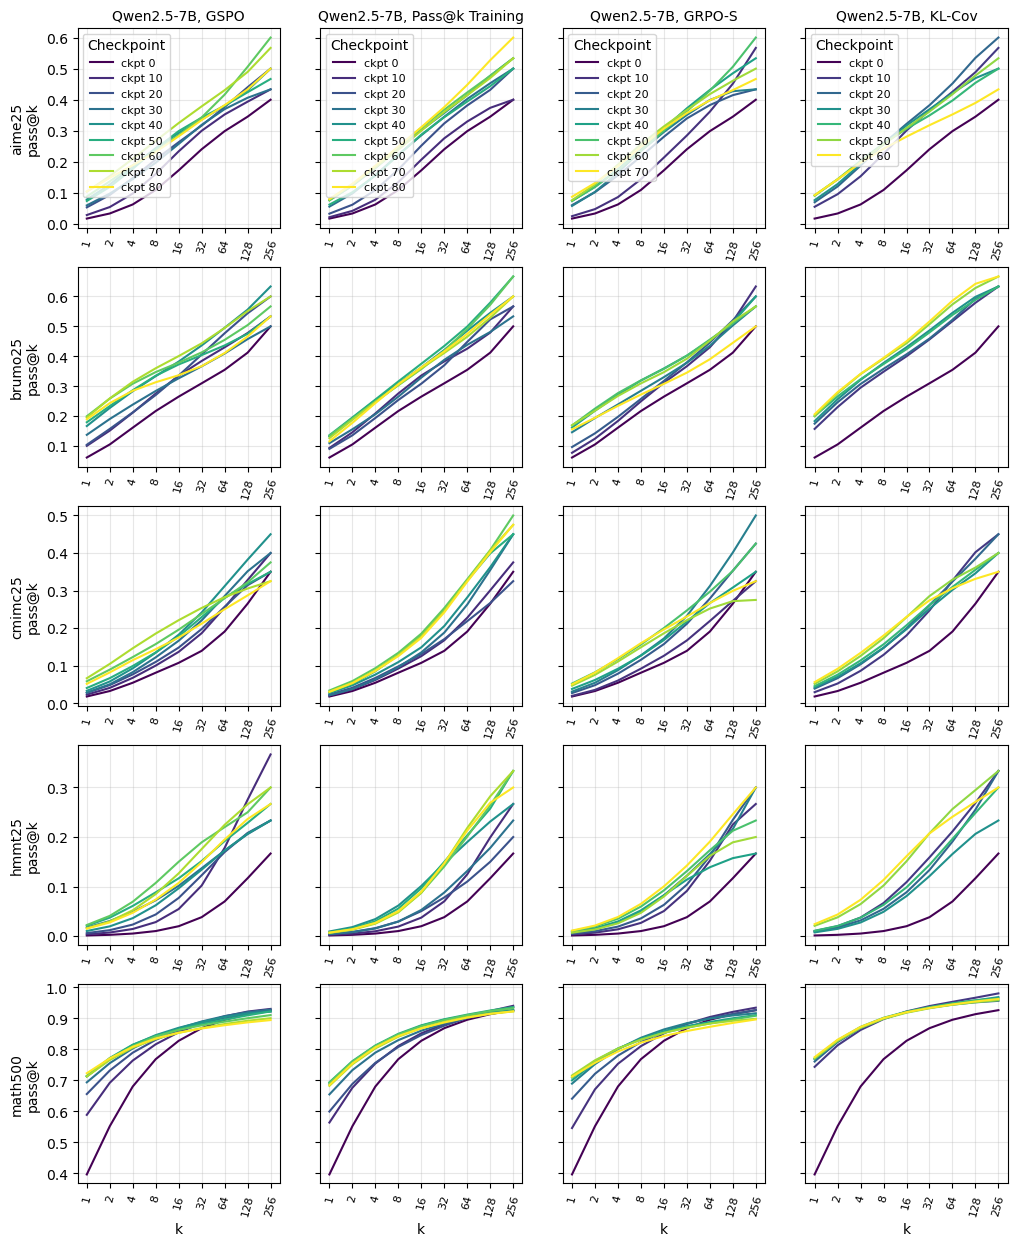

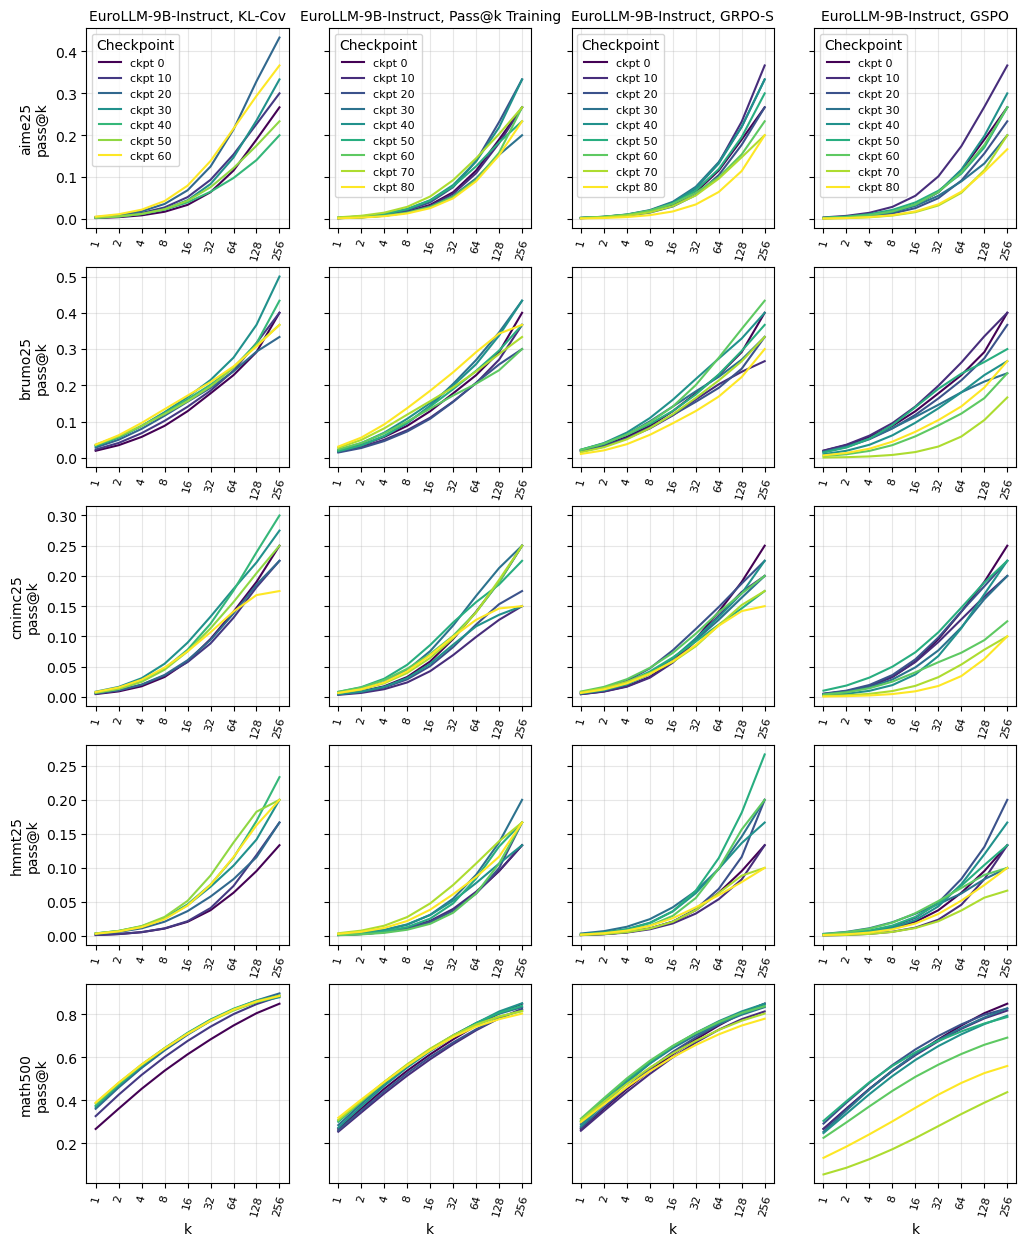

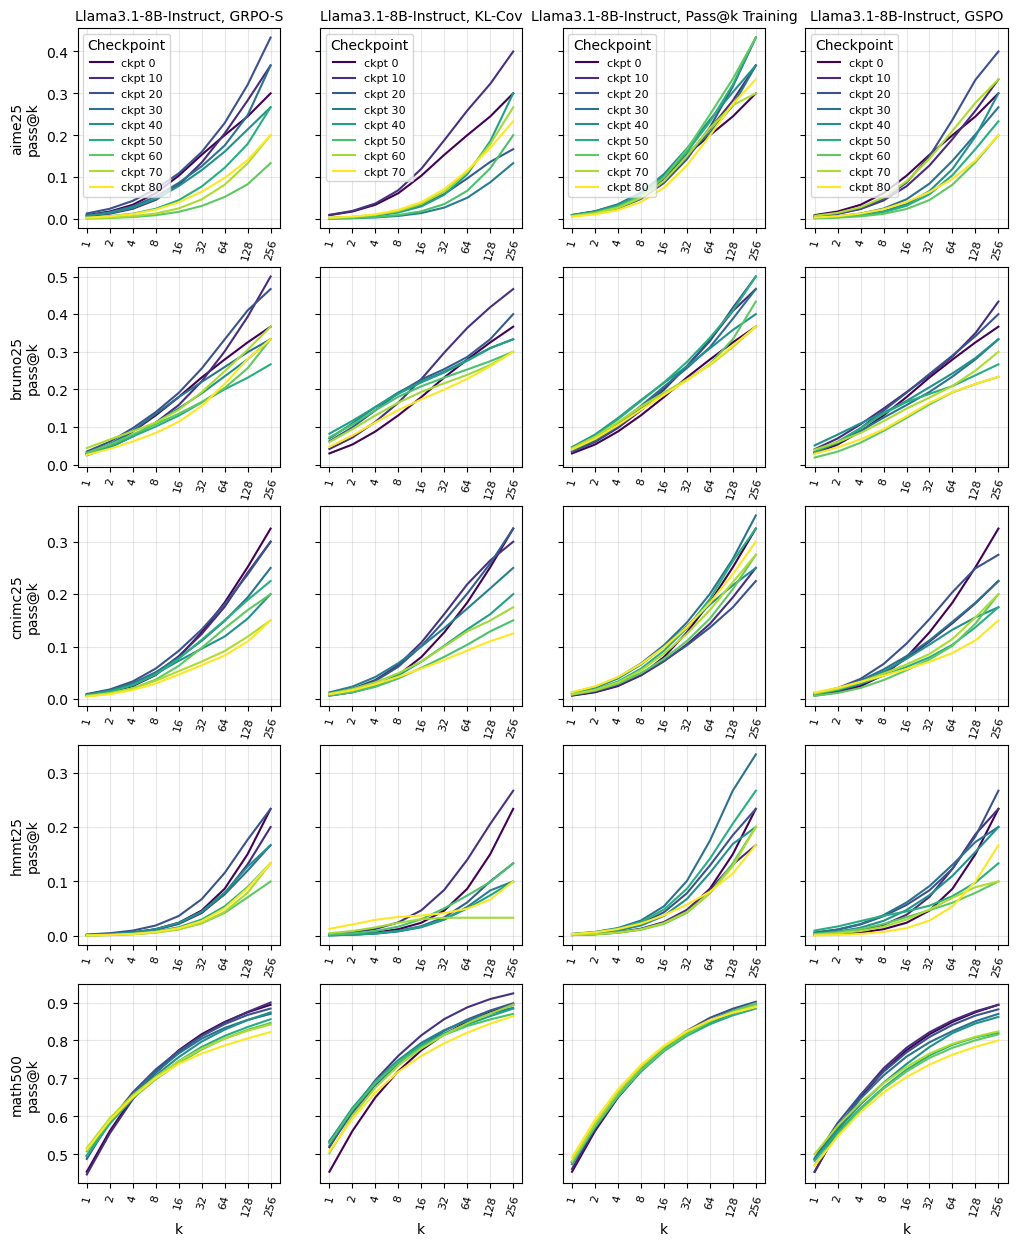

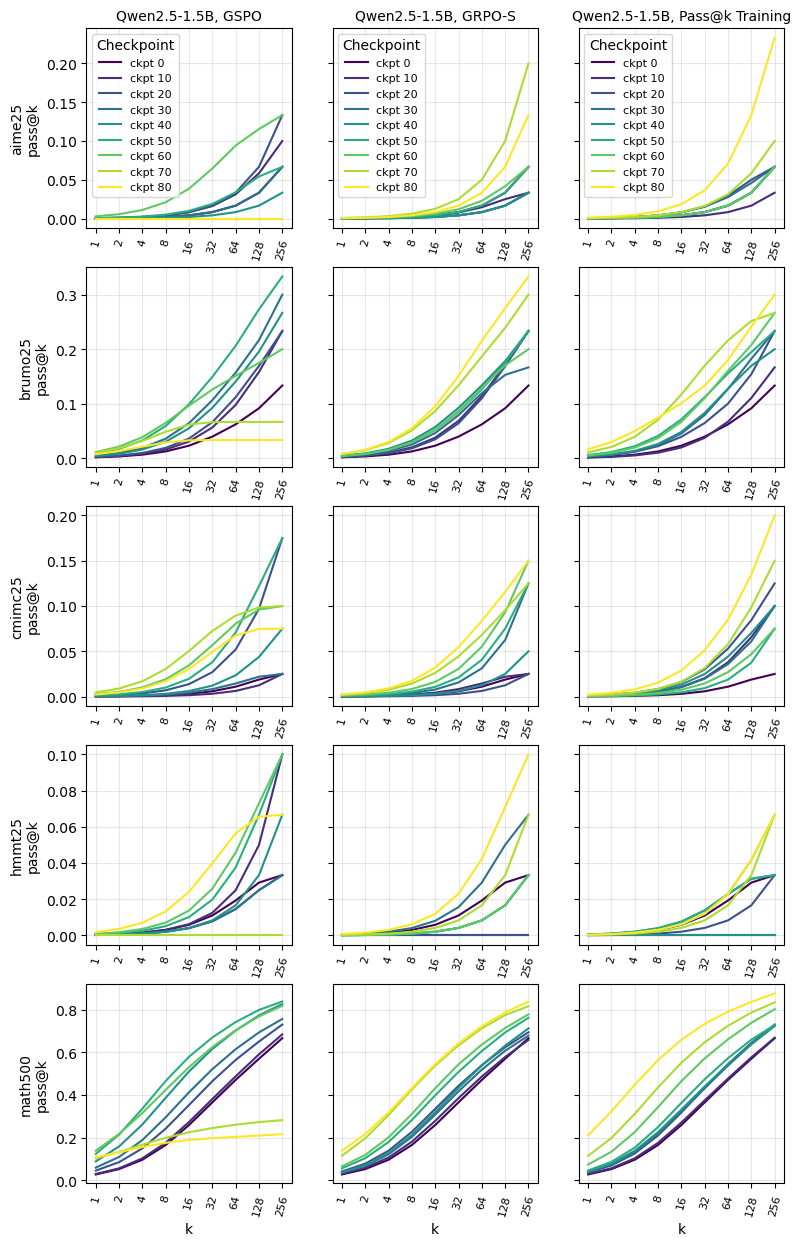

In [39]:
for m in models:
    plot_pass_rates({k : v for k,v in passk.items() if m in k})

In [50]:
def plot_final_delta_histograms(per_question_passrates, passat_value=1, bins=30):
    """
    Plot histograms of per-question passrate changes between first and last checkpoint,
    per method and per dataset, with consistent bins across all subplots.
    
    Args:
        per_question_passrates: dict[method][checkpoint][dataset] -> np.array of per-question pass rates
        bins: int, number of histogram bins
    """
    methods = list(per_question_passrates.keys())
    n_methods = len(methods)

    # Collect all dataset names
    datasets = sorted({
        ds for method_data in per_question_passrates.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    n_datasets = len(datasets)
    passat_index = int(np.log2(passat_value)) # 1 -> 0, 2 -> 1, 4 -> 2, ...

    # Compute global min/max Δ for consistent binning
    all_deltas = []
    for method in methods:
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        first_ckpt = checkpoints[0]
        last_ckpt = checkpoints[-1]
        for dataset in datasets:
            if dataset in method_data.get(first_ckpt, {}) and dataset in method_data.get(last_ckpt, {}):
                first_passrates, last_passrates = method_data[first_ckpt][dataset][:, passat_index], method_data[last_ckpt][dataset][:, passat_index]
                delta = last_passrates - first_passrates
                delta = np.clip(delta, -1, 1)
                all_deltas.append(delta)
    if len(all_deltas) == 0:
        print("No data available to plot")
        return
    all_deltas = np.concatenate(all_deltas)
    vmin, vmax = all_deltas.min(), all_deltas.max()

    # Create subplots
    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(3 * n_methods, 3 * n_datasets),
        squeeze=False,
        sharex=True,
        sharey=False
    )

    for j, method in enumerate(methods):
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        first_ckpt = checkpoints[0]
        last_ckpt = checkpoints[-1]

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            if dataset not in method_data.get(first_ckpt, {}) or dataset not in method_data.get(last_ckpt, {}):
                ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
                continue

            first_passrates, last_passrates = method_data[first_ckpt][dataset][:, passat_index], method_data[last_ckpt][dataset][:, passat_index]
            delta = last_passrates - first_passrates
            delta = np.clip(delta, -1, 1)
            mean_delta = np.mean(delta)

            # Custom colored histogram: separate negative and positive bins
            counts, bin_edges = np.histogram(delta, bins=bins, range=(vmin, vmax))

            for k in range(len(counts)):
                left = bin_edges[k]
                right = bin_edges[k+1]
                center = 0.5 * (left + right)

                if center < 0:
                    color = "lightblue"
                elif center > 0:
                    color = "lightcoral"
                else:
                    color = "gray"

                ax.bar(center, counts[k],
                    width=(right - left),
                    align='center',
                    color=color,
                    edgecolor='black',
                    alpha=0.3)

            # Plot vertical line for mean
            line = ax.axvline(mean_delta, color='black', alpha=0.8, linewidth=1)

            # Add legend with mean
            ax.legend([line], [f'Mean: {mean_delta:.2f}'], fontsize=8)
            mo, me = method.split('__')
            ax.set_title(f"{model_name_mapper[mo]}, {method_name_mapper[me]}" if i==0 else "", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{dataset}\nCount")
            ax.set_xlabel(f"Δ pass@{passat_value} (last - first)")
            ax.grid(True, alpha=0.3)

    plt.suptitle(f"Per-question Δ (last - first) pass@{passat_value} histograms", fontsize=16, y=1.02)
    plt.tight_layout()

    # Save as vector PDF
    models = set([m.split('__')[0]for m in methods])
    ms = set([m.split('__')[1]for m in methods])
    outfile = f"pass@{passat_value}_hist__Models:{'--'.join(models)}__Methods:{'--'.join(ms)}.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

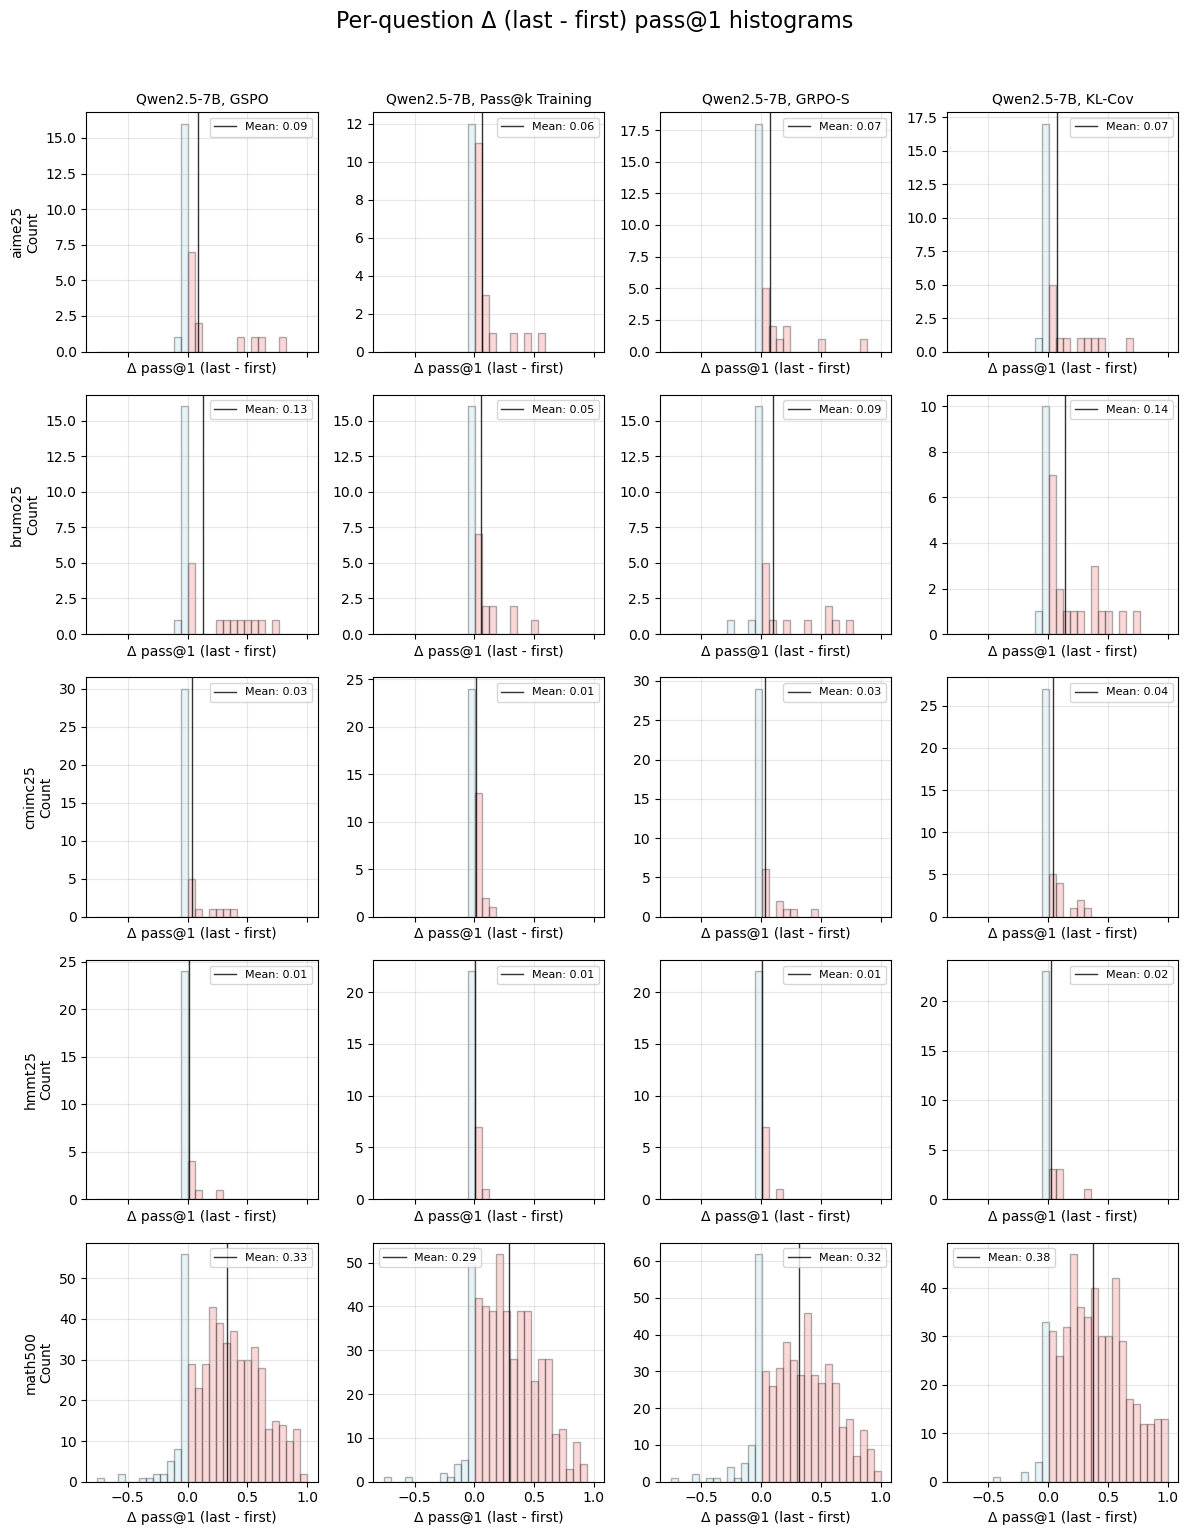

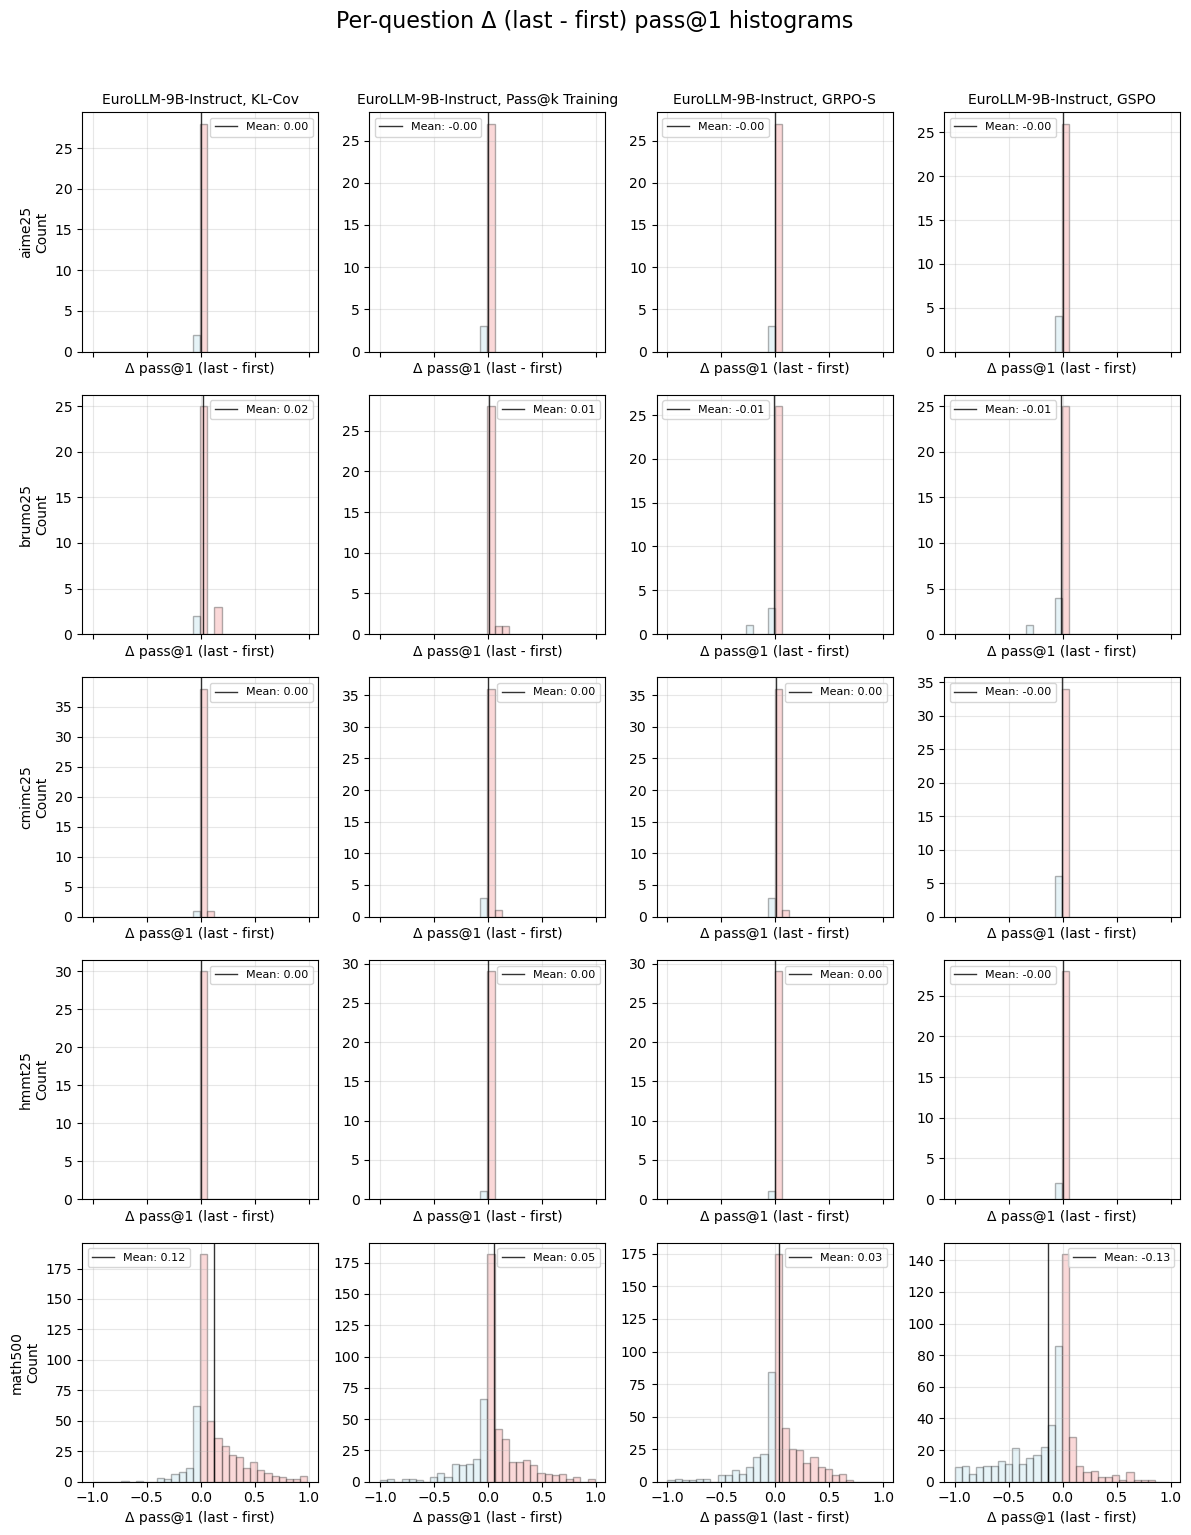

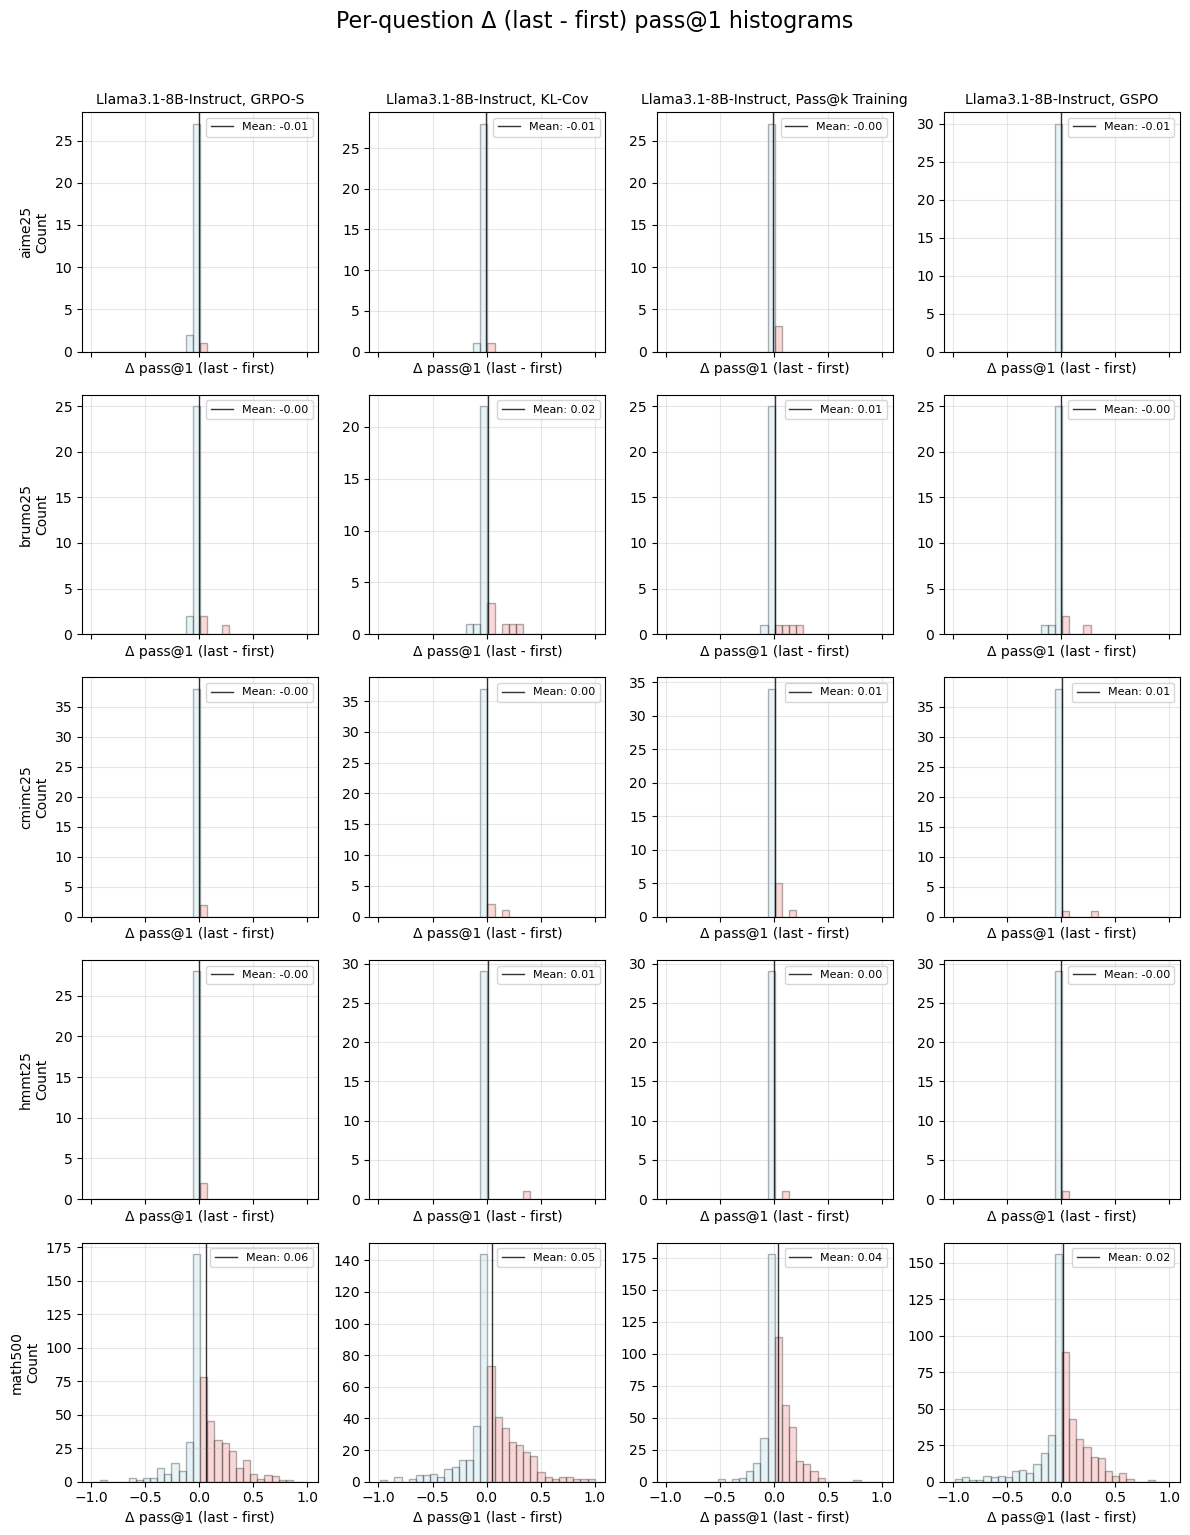

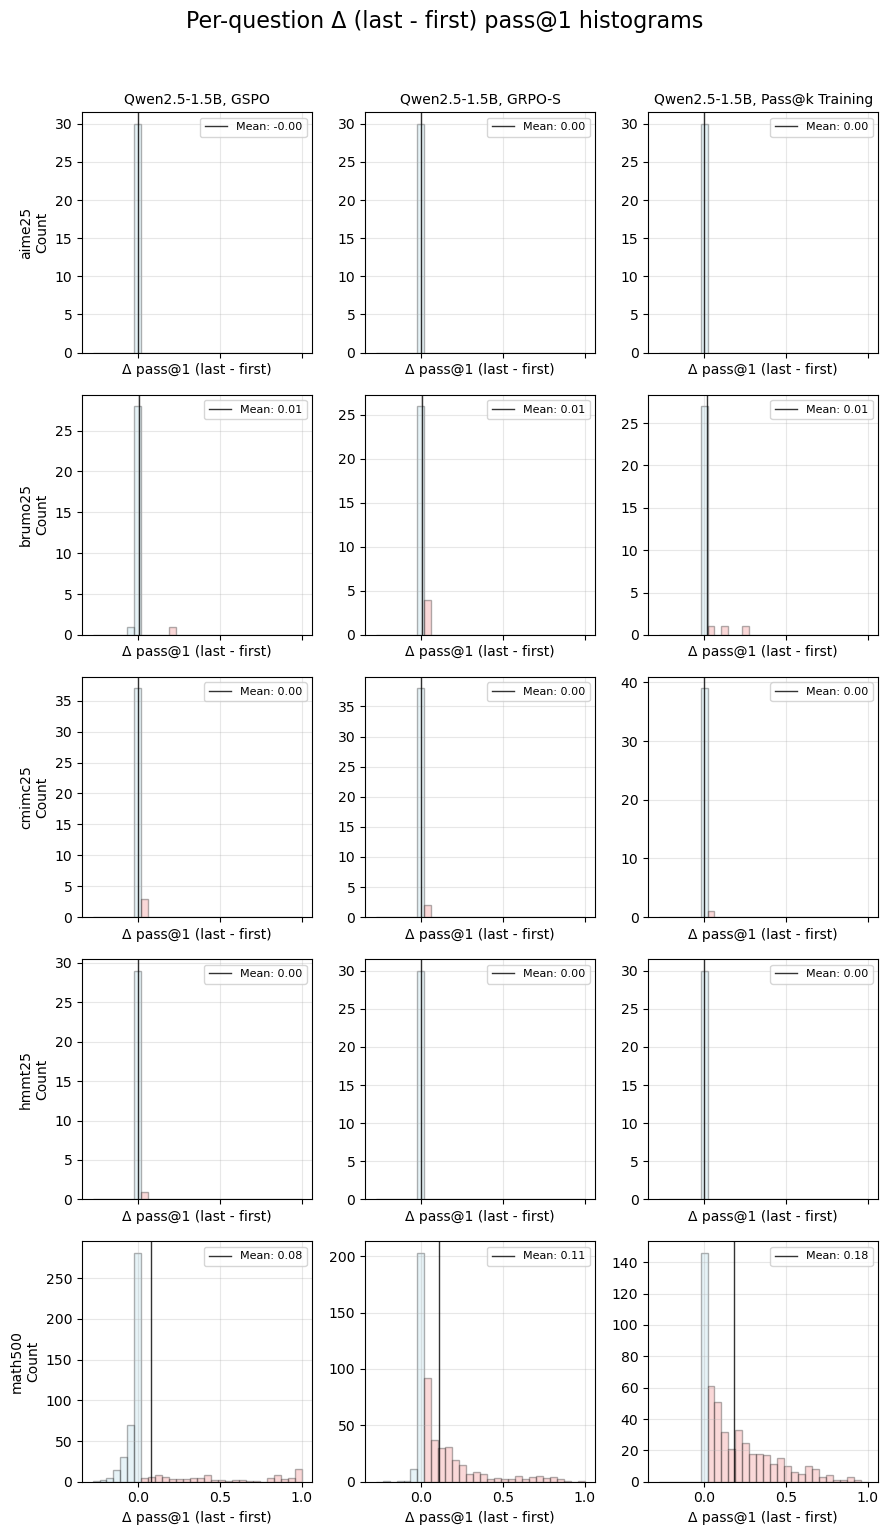

In [52]:
for m in models:
    plot_final_delta_histograms({k : v for k,v in passk.items() if m in k}, passat_value=1)

In [53]:
# preservation/shrinkage/expansion tables.
def compute_PSE(subset : dict) -> dict:
    """
        Computes Preservation, Shrinkage and Expansion for all checkpoints. We're comparing against the base model
        and against the previous checkpoint to uncover training dynamics.
    """

    ret = {}
    for key, checkpoints in subset.items():
        base_pass256 = {dataset_name : passk_values[:, -1].astype(bool) for dataset_name, passk_values in checkpoints['0'].items()}
        ret[key] = {}
        for i_str, passk_values in checkpoints.items():
            if i_str == '0':
                prev_pass256 = base_pass256
                continue
            ret[key][i_str] = {}

            cur_pass256 = {dataset_name : passk_values[:, -1].astype(bool) for dataset_name, passk_values in passk_values.items()}
            for dataset_name, cur_passk_values in cur_pass256.items():
                ret[key][i_str][dataset_name] = {}

                # PSE when compared to previous checkpoints pass@256
                prev_passk_values = prev_pass256[dataset_name]
                expansion = sum(cur_passk_values & ~prev_passk_values)
                shrinkage = sum(~cur_passk_values & prev_passk_values)
                preservation_solved = sum(cur_passk_values & prev_passk_values)
                preservation_unsolved = sum(~cur_passk_values & ~prev_passk_values)

                ret[key][i_str][dataset_name]['previous'] = {
                    "expansion" : expansion,
                    "shrinkage" : shrinkage,
                    "preservation_solved" : preservation_solved,
                    "preservation_unsolved" : preservation_unsolved
                }

                # PSE when compared to base model
                base_passk_values = base_pass256[dataset_name]
                expansion = sum(cur_passk_values & ~base_passk_values)
                shrinkage = sum(~cur_passk_values & base_passk_values)
                preservation_solved = sum(cur_passk_values & base_passk_values)
                preservation_unsolved = sum(~cur_passk_values & ~base_passk_values)

                ret[key][i_str][dataset_name]['base'] = {
                    "expansion" : expansion,
                    "shrinkage" : shrinkage,
                    "preservation_solved" : preservation_solved,
                    "preservation_unsolved" : preservation_unsolved
                }

            prev_pass256 = cur_pass256
    return ret

In [76]:
def plot_pse(subset : dict):
    """
        subset has structure:
            methodX:
                step10:
                    datasetA:
                        previous:
                            expansion: 10, shrinkage: 2, preserv....
                        base:
                            expansion: 3, shrinkage: 4, preserv....
                    datasetB:
                        ...
                step20:
                    ...
            methodY:
                ...
    
    """                 

    methods = list(subset.keys())
    datasets = list(subset[methods[0]]['10'].keys()) # take dataset names for first method, checkpoint 10. Should always be present.
    
    checkpoints = sorted(
        [ckpt for ckpt in subset[methods[0]].keys()],
        key=lambda x: int(x)
    )
    name_mapper = {
        "preservation_unsolved": "Remains unsolved",
        "preservation_solved": "Remains solved",
        "expansion": "Expansion",
        "shrinkage": "Shrinkage",
    }
    colors = {
        "preservation_unsolved": "lightgray",
        "preservation_solved": "tab:blue",
        "expansion": "tab:green",
        "shrinkage": "tab:red",
    }

    fig, axes = plt.subplots(
        ncols=len(methods),
        nrows=len(datasets),
        sharex='col',
        figsize=(3 * len(methods), 2 * len(datasets)),
    )

    # Make axes always 2D for consistent indexing
    if len(datasets) == 1:
        axes = axes[np.newaxis, :]
    if len(methods) == 1:
        axes = axes[:, np.newaxis]

    for col, method in enumerate(methods):
        checkpoints = sorted(
            subset[method].keys(),
            key=lambda x: int(x)
        )

        for row, dataset in enumerate(datasets):
            ax = axes[row, col]
            bottoms = np.zeros(len(checkpoints))

            for metric in [
                "preservation_unsolved",
                "preservation_solved",
                "expansion",
                "shrinkage",
            ]:
                values = []
                for ckpt in checkpoints:
                    stats = subset[method][ckpt][dataset]["base"]
                    total = sum(stats.values())
                    values.append(stats[metric] / total if total > 0 else 0.0)

                ax.bar(
                    checkpoints,
                    values,
                    bottom=bottoms,
                    color=colors[metric],
                    width=0.8,
                    label=name_mapper[metric] if (row == 0 and col == 0) else None,
                )
                bottoms += np.array(values)

            if row == 0:
                mo, me = method.split('__')
                ax.set_title(f"{model_name_mapper[mo]}, {method_name_mapper[me]}")
            if col == 0:
                ax.set_ylabel(dataset + "\n % pass@256")

            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [0, 25, 50, 75, 100])
            if row == len(datasets) - 1:
                ax.set_xlabel("Checkpoint")
                ax.tick_params(axis="x", rotation=45)

    # Legend below the figure
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.02),
    )

    fig.suptitle("Expansion/Shrinkage Dynamics (stacked percentages vs base) pass@256", fontsize=16, y=0.95)
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    # Save as vector PDF
    models = set([m.split('__')[0]for m in methods])
    ms = set([m.split('__')[1]for m in methods])
    outfile = f"pse_stacked_perc__Models:{'--'.join(models)}__Methods:{'--'.join(ms)}.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    

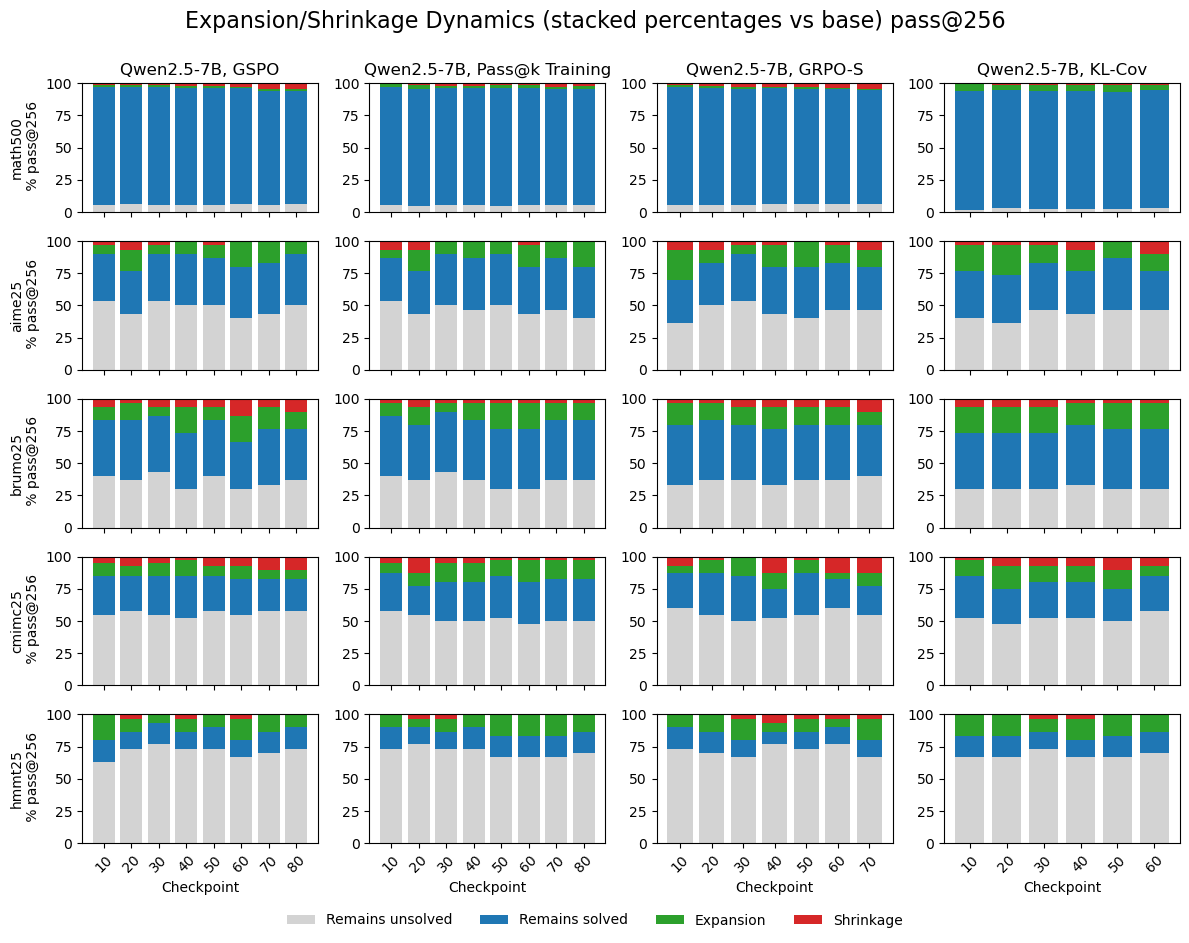

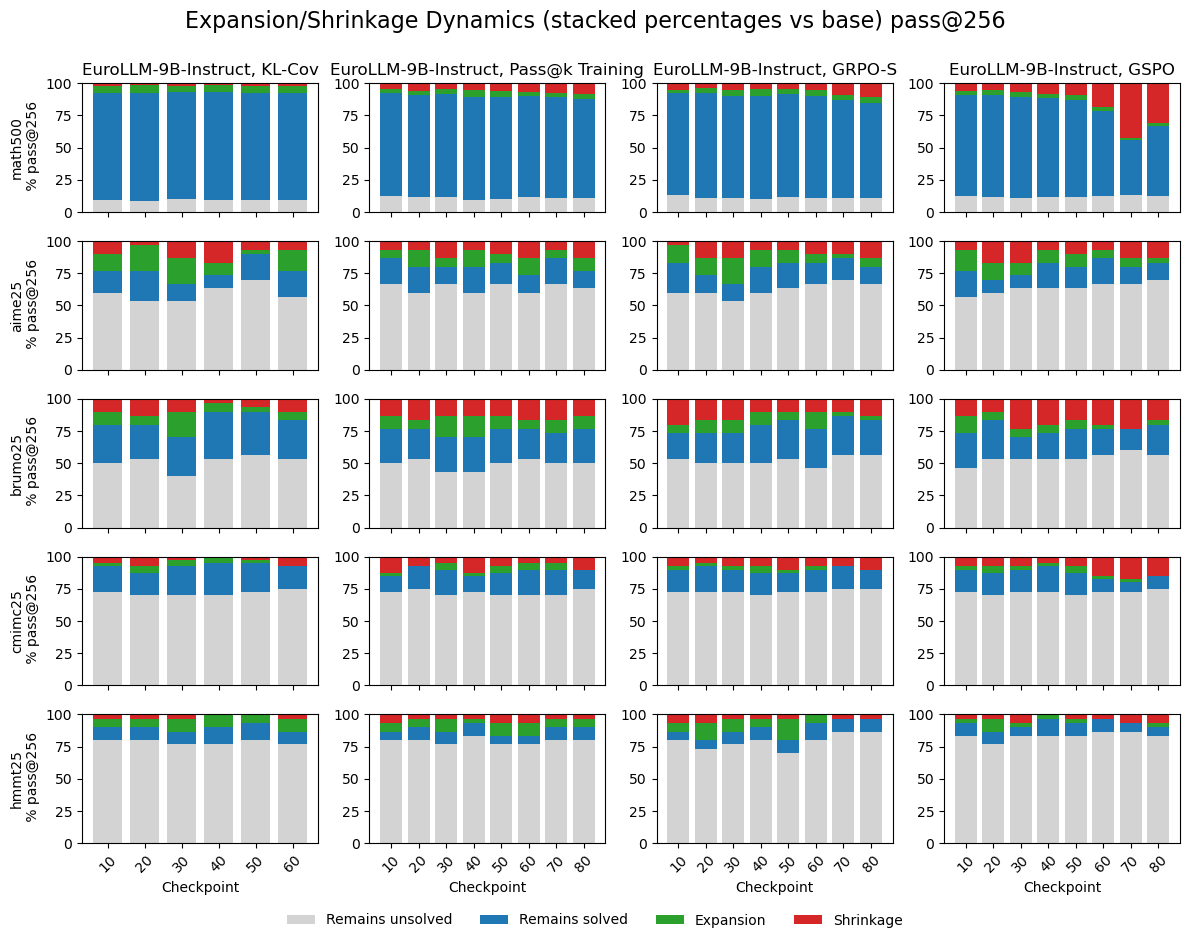

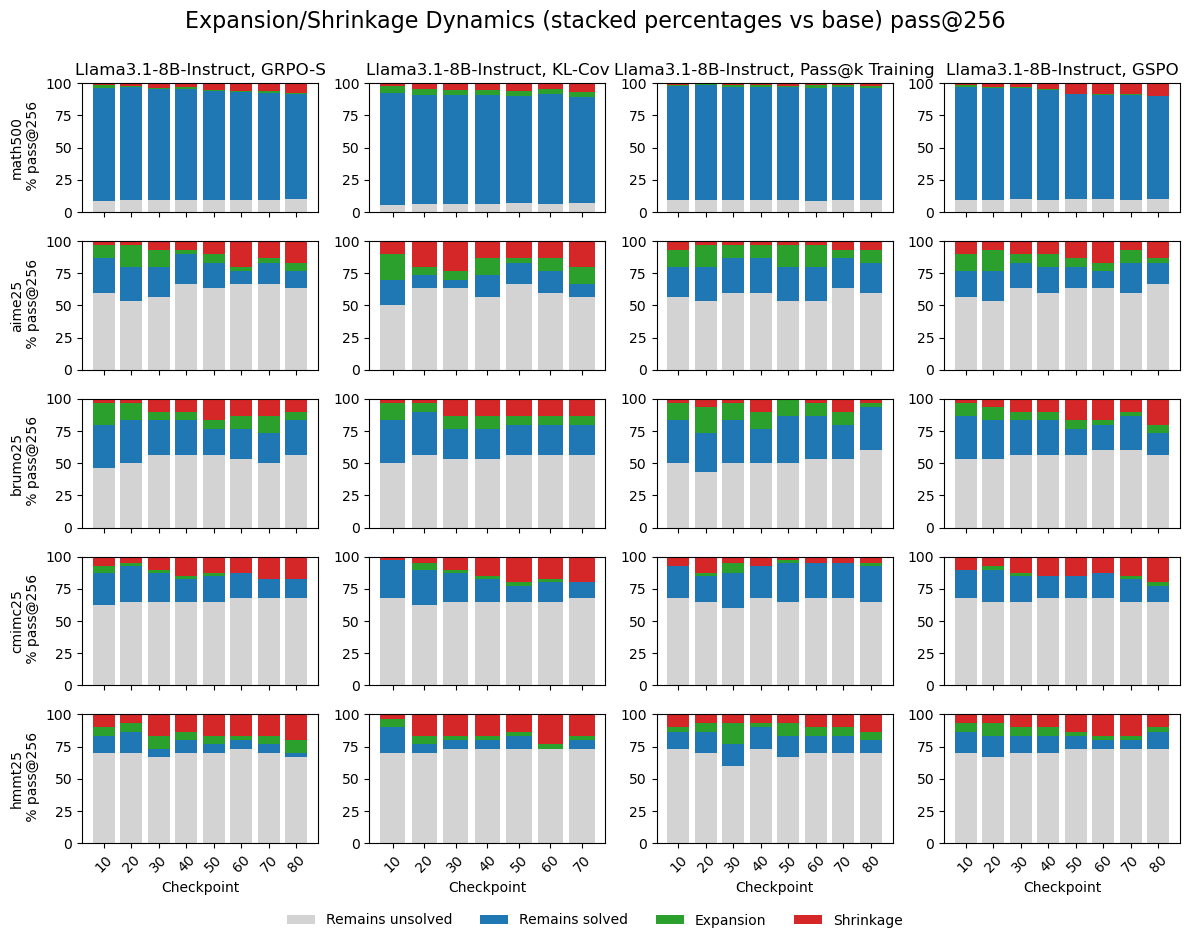

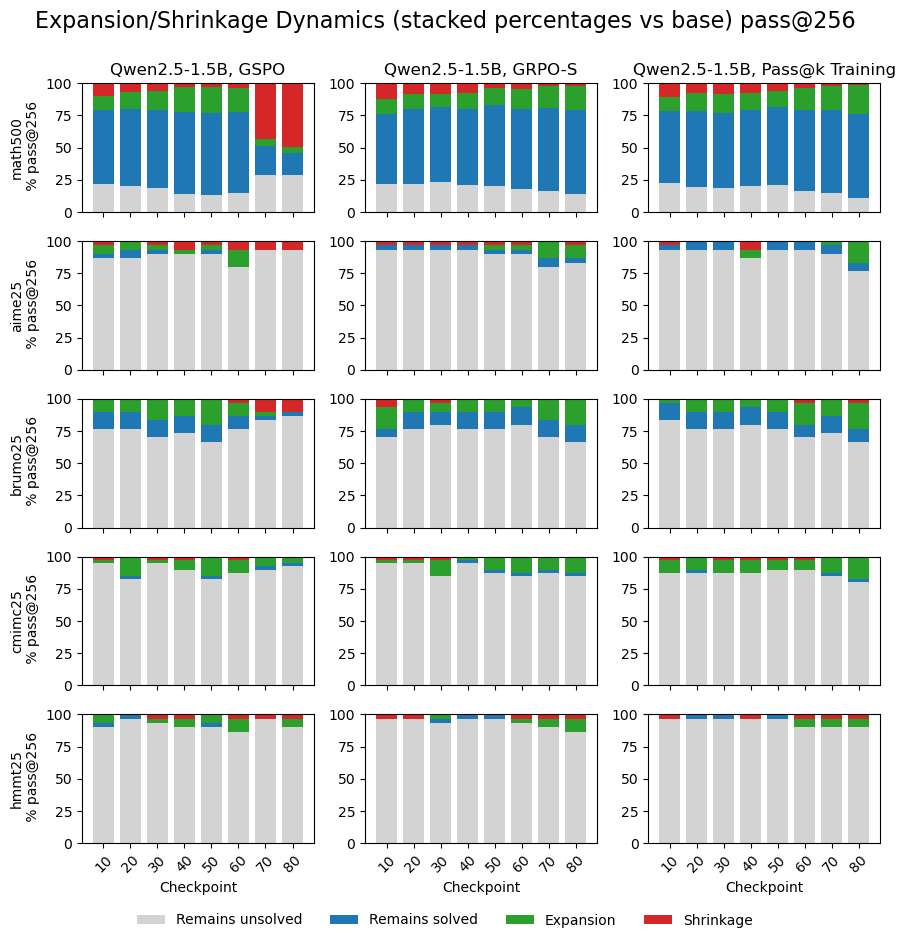

In [78]:
for m in models:
    pse = compute_PSE({k : v for k, v in passk.items() if m in k})
    plot_pse(pse)

In [80]:
def preprocess_pse(subset : dict):
    """
        Returns dicts of shape:
            1) expansion:
            
            methodX:
                [1, 0, 1, 0, ..., 1] (pass@256 of methodX = 1 & pass@256 of base=0)
            methodY
                [1, 0, 1, 0, ..., 1] (pass@256 of methodY = 1 & pass@256 of base=0)
            ...

            2) shrinkage:
            methodX:
                [1, 0, 0, 1, ..., 1] (pass@256 of methodX = 0 & pass@256 of base=1)
            methodY
                [1, 0, 1, 1, ..., 0] (pass@256 of methodY = 0 & pass@256 of base=1)
            ...
    """
    def get_last_index(keys) -> str:
        return str(sorted(list(map(int, list(keys))), reverse=True)[0])
    
    expansion, shrinkage = {}, {}
    for method in subset.keys():
        base_pass256 = np.concat(
            list(subset[method]['0'].values()), 
            axis=0
        )[:, -1].astype(bool)
        last_pass256 = np.concat(
            list(subset[method][get_last_index(subset[method].keys())].values()), 
            axis=0
        )[:, -1].astype(bool)

        e, s = ~base_pass256 & last_pass256, base_pass256 & ~last_pass256
        mo, me = method.split('__')
        pretty_name = f"{model_name_mapper[mo]}, {method_name_mapper[me]}"
        expansion[pretty_name] = e; shrinkage[pretty_name] = s
    return expansion, shrinkage

In [88]:
import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import from_indicators, plot

def plot_upset(expansion, shrinkage):
    """
    Erstellt UpSet-Plots mit spezifischen Farben und Sortierung.
    Expansion: Light Green
    Shrinkage: Light Red
    """
    datasets = [
        (expansion, "Expansion (pass@256 Base=0, RL=1)", "#90EE90", "expansion"), # Light Green
        (shrinkage, "Shrinkage (pass@256 Base=1, RL=0)", "#FFCCCB", "shrinkage")   # Light Red
    ]

    for data, title, color, handle in datasets:
        if not data:
            continue
            
        df = pd.DataFrame(data)
        upset_data = from_indicators(indicators=df.columns, data=df)
        fig = plt.figure(figsize=(5, 4))
        
        # sort_by='cardinality' sortiert nach der Größe der Schnittmengen
        plot(upset_data, 
             fig=fig, 
             facecolor=color, 
             sort_by='cardinality', 
             show_counts=True)
        
        fig.suptitle(title, fontsize=16, fontweight='bold')
        plt.show()
        
        # Save as vector PDF
        methods = list(expansion.keys())
        models = set([m.split(', ')[0]for m in methods])
        ms = set([m.split(', ')[1]for m in methods])
        outfile = f"UpSet_{handle}_Models:{'--'.join(models)}__Methods:{'--'.join(ms)}.pdf"
        fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

In [89]:
import warnings
warnings.filterwarnings("ignore")

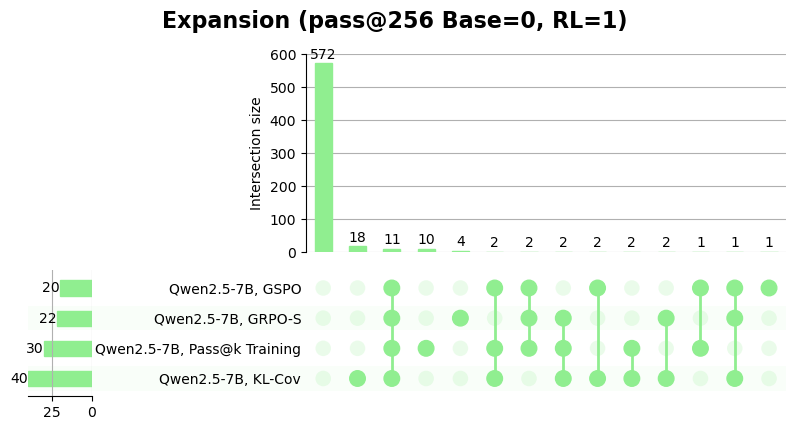

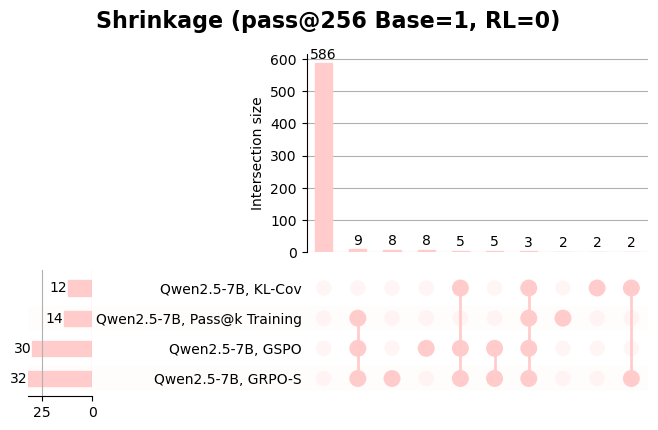

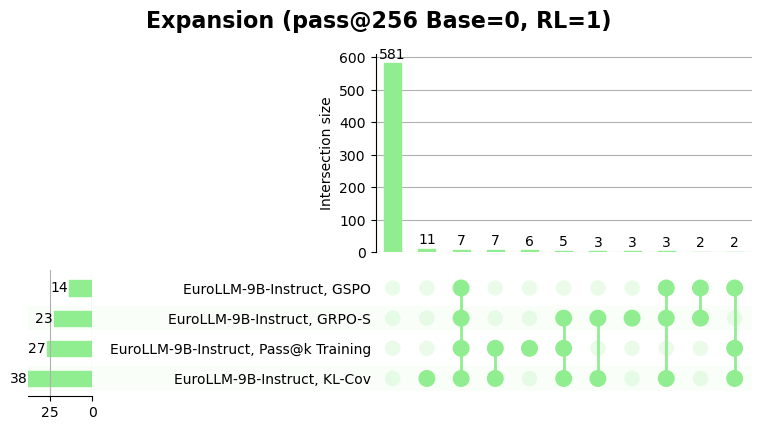

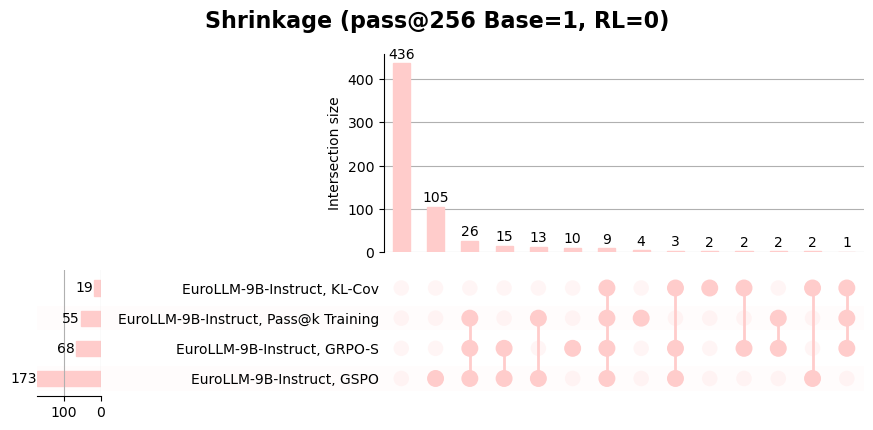

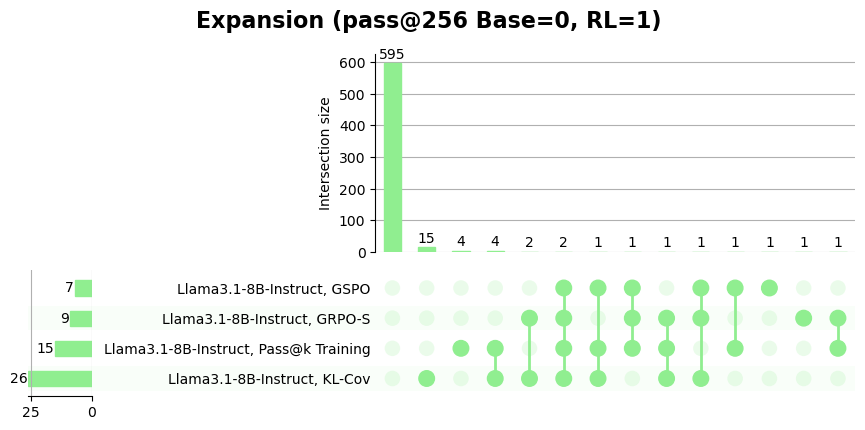

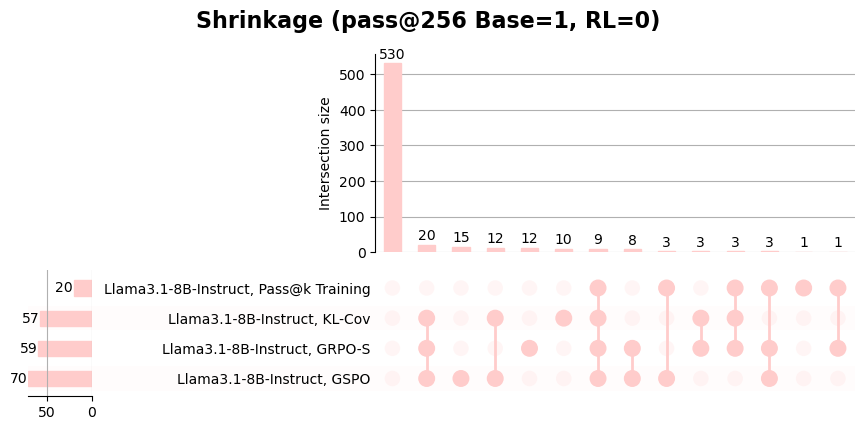

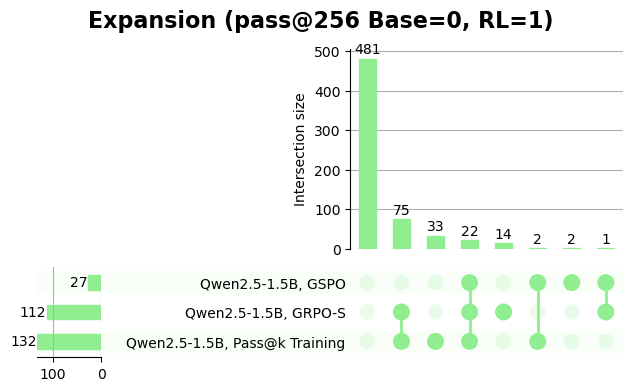

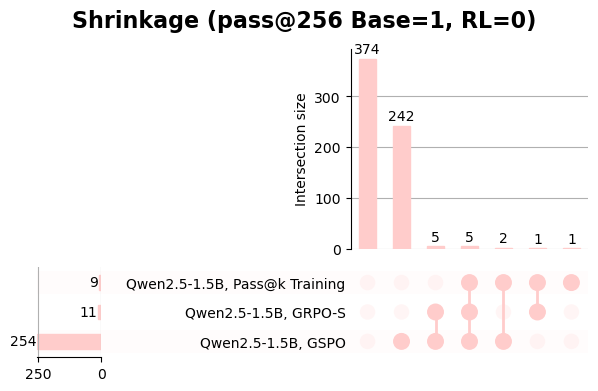

In [91]:
for m in models:
    subset = {k : v for k ,v in passk.items() if m in k}
    expansion, shrinkage = preprocess_pse(subset)
    plot_upset(expansion, shrinkage)    